week6 lab

In [4]:
from datetime import datetime, timedelta

import cmcrameri as cmc  # noqa: F401
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pandas as pd
import pystac_client
import rioxarray  # noqa: F401
import xarray as xr
from odc.geo.geobox import GeoBox
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

Part 1: Data Aquisiton, Preprocessing, and Feature Engineering

In [2]:
# Define spatial and temporal extent for Vienna
dx = 0.0006  # ~60m resolution
epsg = 4326

# Vienna area bounds
vienna_bounds = (16.32, 47.86, 16.9, 48.407)

# Temporal extent: March 2020
start_date = datetime(year=2020, month=3, day=1)
end_date = start_date + timedelta(days=30)

date_query = f"{start_date.strftime('%Y-%m-%d')}/{end_date.strftime('%Y-%m-%d')}"

# Search for Sentinel-2 data
stac_client = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")

vienna_items = stac_client.search(
    bbox=vienna_bounds,
    collections=["sentinel-2-l2a"],
    datetime=date_query,
    query={"eo:cloud_cover": {"lt": 50}},  # skip heavily cloudy scenes
    limit=100,
).item_collection()

print(f"Vienna: {len(vienna_items)} scenes found")

Vienna: 19 scenes found


Load the training data from vienna_samples.parquet in the repo. If you haven't worked with GeoParquet data before, this is very simple. Just use gpd.read_parquet(). 

In [7]:
# define a geobox for my region
geobox = GeoBox.from_bbox(vienna_bounds, crs=f"epsg:{epsg}", resolution=dx)

# lazily combine items into a datacube
dc = odc.stac.load(
    vienna_items,
    bands=["scl", "red", "green", "blue", "nir"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)
dc

<xarray.Dataset> Size: 135MB
Dimensions:      (latitude: 913, longitude: 967, time: 17)
Coordinates:
  * latitude     (latitude) float64 7kB 48.41 48.41 48.41 ... 47.86 47.86 47.86
  * longitude    (longitude) float64 8kB 16.32 16.32 16.32 ... 16.9 16.9 16.9
  * time         (time) datetime64[ns] 136B 2020-03-08T09:57:16.896000 ... 20...
    spatial_ref  int32 4B 4326
Data variables:
    scl          (time, latitude, longitude) uint8 15MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    red          (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    nir          (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

f:\GitHub\musa-650-spring2026\.venv\Lib\site-packages\rasterio\warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
f:\GitHub\musa-650-spring2026\.venv\Lib\site-packages\rasterio\warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


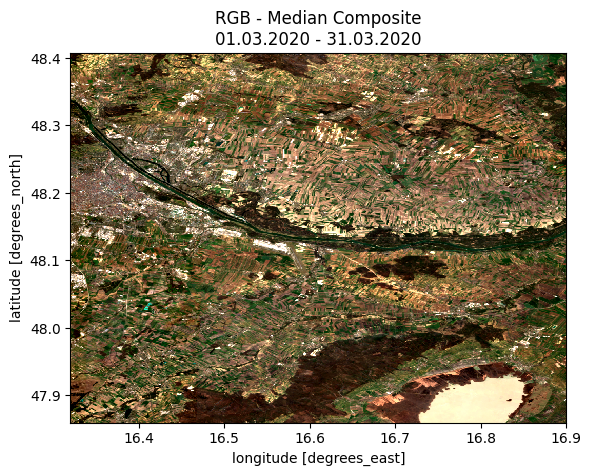

In [8]:
# define a mask for valid pixels (non-cloud)


def is_valid_pixel(data):
    # include only vegetated, not_vegitated, water, and snow
    return ((data > 3) & (data < 7)) | (data == 11)


dc["valid"] = is_valid_pixel(dc.scl)

# compute the masked median
rgb_median = (
    dc[["red", "green", "blue"]]
    .where(dc.valid)
    .to_dataarray(dim="band")
    .median(dim="time")
    .astype(int)
)

# plot the median composite
title_rgb = (
    "RGB - Median Composite"
    + f"\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
rgb_median.plot.imshow(robust=True).axes.set_title(title_rgb)
plt.show()